# Week 9 — Phase 1: closing the Week 8/8.5 sample-efficiency result

This notebook is a **teaching and reporting notebook**. It reads validated machine-readable outputs; it does not retune an acquisition rule or rewrite the frozen Week 8.5 protocol.

The new H=320 work is a **post-hoc horizon-extension closing diagnostic**.

In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import display, Image, Markdown

ROOT = Path.cwd().resolve().parents[1] if Path.cwd().name == 'week_09' else Path.cwd()
OUT = ROOT / 'outputs' / 'week9_phase1_close_week8'
summary = json.loads((OUT / 'summary.json').read_text(encoding='utf-8'))
summary['analysis_status']

'posthoc_horizon_extension_closing_diagnostic'

## 1. Question and why we are doing this

Week 8.5 confirmed faster Fold-B1-q20 learning by Binary Margin over matched Random using AULC from budgets 16–80. The remaining practical question was whether the persistent 0.80 target crossings that were unresolved at H=160 would become observable by H=320, and whether a defensible query-saving statement followed.

In [2]:
questions = pd.DataFrame({
    'Question': [
        'Which method improves faster over the query budget?',
        'Which method has the better model at a fixed final budget?',
        'How many paths have a confirmed persistent 0.80 Fold-B1-q20 crossing?',
    ],
    'Correct metric': ['AULC', 'Terminal accuracy / recall / specificity', 'Confirmation-aware crossing rate'],
})
display(questions)

,Question,Correct metric
0,Which method improves faster over the query bu...,AULC
1,Which method has the better model at a fixed f...,Terminal accuracy / recall / specificity
2,How many paths have a confirmed persistent 0.8...,Confirmation-aware crossing rate


**What do we see?** The scientific questions require three different estimands.

**Why does it matter?** Using the correct metric prevents a learning-speed result from being mislabeled as final-model quality.

**What can we claim?** AULC and terminal metrics are complementary.

**What can we NOT claim?** AULC is not terminal accuracy, and q20 is not the physical boundary.

## 2. Existing frozen Week 8.5 state

Ground truth is the **manual `has_keyhole` label**. Inputs are `P`, `VX`, `LS`, and `ST`; **ST means substrate temperature**. Fold-B1-q20 is the 17 held-out test simulations with the smallest B1 distance within each 81-row fold. It is an empirical near-boundary evaluation subset.

In [3]:
frozen = pd.DataFrame([
    ['Population', '405 simulations: 73 Keyhole, 332 Conduction'],
    ['Outer design', '20 repeats × 5 folds = 100 runs'],
    ['Initial design', '16 feature-only, arm-matched queries'],
    ['Random', '30 continuations within each outer run'],
    ['Frozen AULC Margin', summary['frozen_AULC']['binary_margin']],
    ['Frozen AULC matched Random', summary['frozen_AULC']['matched_binary_random']],
    ['Frozen AULC delta', summary['frozen_AULC']['margin_minus_random']],
], columns=['Item', 'Frozen value'])
display(frozen)

,Item,Frozen value
0,Population,"405 simulations: 73 Keyhole, 332 Conduction"
1,Outer design,20 repeats × 5 folds = 100 runs
2,Initial design,"16 feature-only, arm-matched queries"
3,Random,30 continuations within each outer run
4,Frozen AULC Margin,0.81352
5,Frozen AULC matched Random,0.77622
6,Frozen AULC delta,0.0373


**What do we see?** The population, labels, splits, initial designs, models, and seeds were inherited unchanged.

**Why does it matter?** The H=320 work continues the same trajectories rather than creating a new method search.

**What can we claim?** The frozen AULC result remains the confirmatory Week 8.5 result.

**What can we NOT claim?** The post-hoc extension cannot retroactively change the Week 8.5 decision ledger.

## 3. Reproducibility validation through H=160

Every H=160 checkpoint was read from the pinned compressed bundle. The ordered 160-query prefix, split membership, initial 16 queries, Random order, fit seeds, and saved metrics were validated before any extension output was accepted.

In [4]:
validation = json.loads((OUT / 'validation_report.json').read_text(encoding='utf-8'))
checks = pd.DataFrame(validation['checks'])
display(checks[['check_id', 'status']])
assert validation['status'] == 'PASS'

,check_id,status
0,frozen_population_405,PASS
1,manual_has_keyhole_unchanged,PASS
2,frozen_source_hashes,PASS
3,split_and_initial_design_exact,PASS
4,historical_query_prefixes_exact,PASS
5,historical_random_orders_exact,PASS
6,all_H320_trajectories_complete,PASS
7,all_completed_payloads_fully_validated,PASS
8,no_test_B1_or_hidden_label_acquisition,PASS
9,crossing_start_and_confirmation_distinguished,PASS


**What do we see?** Historical H=80, H=120, and H=160 crossing counts and burdens reproduce exactly.

**Why does it matter?** An H=320 result is interpretable only after historical identity is preserved.

**What can we claim?** The continuation is anchored to the frozen trajectories.

**What can we NOT claim?** A merely similar rerun would not be the same scientific experiment.

## 4. Horizon extension to 320

Only `binary_margin` and `binary_random` were extended. Margin was refit sequentially because each next query depends on its current classifier. Random used its frozen seeded order; after a persistent crossing was confirmed, intermediate fits were no longer needed, but budget 320 was still fit for terminal performance.

In [5]:
horizon = pd.read_csv(OUT / 'crossing_by_horizon.csv')
display(horizon.pivot(index='horizon', columns='arm', values=['finite_persistent_crossings','finite_rate','unresolved','restricted_mean_query_burden']))

finite_persistent_crossings                 finite_rate                \
arm                   binary_margin binary_random binary_margin binary_random   
horizon                                                                         
80                             90.0        2201.0          0.90      0.733667   
120                            91.0        2394.0          0.91      0.798000   
160                            91.0        2493.0          0.91      0.831000   
200                            91.0        2577.0          0.91      0.859000   
240                            91.0        2644.0          0.91      0.881333   
280                            91.0        2691.0          0.91      0.897000   
320                            91.0        2727.0          0.91      0.909000   

           unresolved               restricted_mean_query_burden                
arm     binary_margin binary_random                binary_margin binary_random  
horizon                                                                         
80               10.0         799.0                        31.85     42.803333  
120               9.0         606.0                        35.47     51.914333  
160               9.0         507.0                        39.07     59.169000  
200               9.0         423.0                        42.67     65.175667  
240               9.0         356.0                        46.27     70.281000  
280               9.0         309.0                        49.87     74.667667  
320               9.0         273.0                        53.47     78.466333

**What do we see?** At H=320, Margin has 91/100 confirmed crossings; Random has 2727/3000.

**Why does it matter?** The longer horizon directly answers how much H=160 right-tail uncertainty was resolved.

**What can we claim?** These are post-hoc attainment diagnostics on the fixed 405-simulation benchmark.

**What can we NOT claim?** They are not preregistered H=320 confirmation or independent physical campaigns.

## 5. Persistent 80% crossing results

`Q` is the **first** checkpoint in a run of three passing checkpoints. The crossing becomes observable only at the **third** checkpoint. Therefore every horizon count below requires `confirmation_budget <= horizon`.

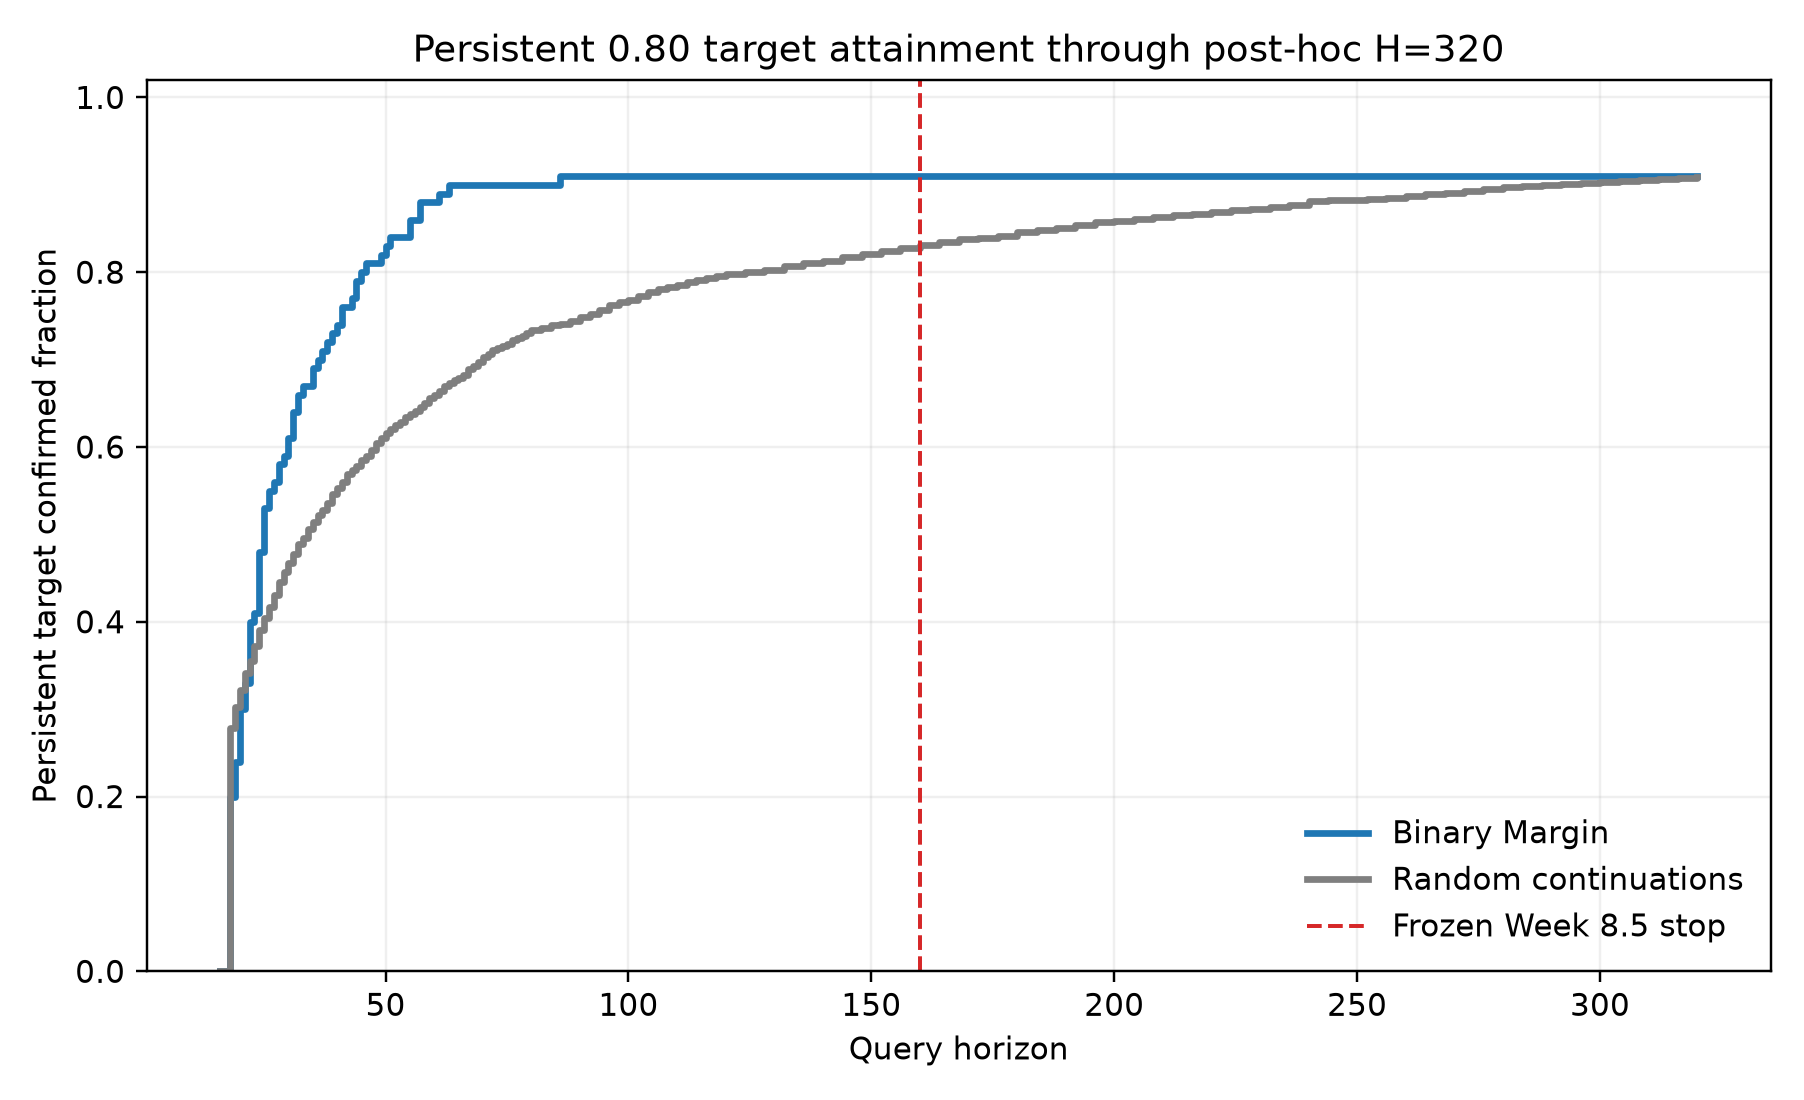

In [6]:
display(Image(filename=str(OUT / 'figures' / '02_persistent_target_attainment_vs_horizon.png')))

**What do we see?** The attainment curves use confirmation time, while the reported burden retains the historical Q-start definition.

**Why does it matter?** This prevents a triple completed after H from being counted as already observed at H.

**What can we claim?** Historical counts are unchanged and later counts use the same definition.

**What can we NOT claim?** A full-H320 Q cannot simply be compared with H to reconstruct earlier censoring.

## 6. Query-saving interpretation

The naive statement “every unresolved Random path has Q>320” is not generally true. If 316 and 320 pass, a future 324 pass could later assign Q=316. The analysis therefore uses **path-specific lower bounds** for the unresolved tail and keeps the H=320 restricted burden descriptive.

In [7]:
claim = json.loads((OUT / 'query_saving_claim_decision.json').read_text(encoding='utf-8'))
display(pd.Series(claim, name='value').to_frame())
display(pd.read_csv(OUT / 'matched_pair_crossing_categories.csv').groupby('category').size().rename('matched comparisons').to_frame())

,value
bootstrap_scope,Descriptive uncertainty under the frozen repea...
design_conditional_bootstrap_lower_bound_positive,False
fixed_benchmark_lower_bound_positive,False
hierarchical_one_sided_95pct_lower_bound_queries,None
margin_all_100_observed,False
matched_category_counts,"{'both_crossed': 2608, 'margin_crossed_random_..."
naive_Qrandom_gt_320_for_every_unresolved_is_valid,False
path_specific_average_saving_lower_bound_queries,None
random_unresolved,273
random_unresolved_guaranteed_Q_gt_320,267


,matched comparisons
category,
both_crossed,2608
margin_crossed_random_unresolved,122
neither_crossed,151
random_crossed_margin_unresolved,119


**What do we see?** An 'at least X queries saved on average' claim is not identified because at least one Margin crossing remains unresolved at H=320.

**Why does it matter?** The statement follows the frozen crossing definition instead of assuming away the unobservable tail.

**What can we claim?** Only the exact sentence in the claim decision is supervisor-safe.

**What can we NOT claim?** The restricted 320-clipped mean is not automatically a mathematical lower bound.

## 7. AULC versus terminal accuracy

| Question | Correct metric |
|---|---|
| Which method learns faster as query budget increases? | AULC |
| Which method has the best model at budget 80? | Terminal metric at 80 |
| Which method has the best model at budget 160? | Terminal metric at 160 |
| Which method has the best model at budget 320? | Terminal metric at 320 |

estimand       binary_margin  binary_random  margin_minus_random
budget subset                                                   
40     B1_q20       0.817059       0.774510             0.042549
       B1_q30       0.870800       0.828760             0.042040
       full81       0.957901       0.944053             0.013848
80     B1_q20       0.832941       0.795863             0.037078
       B1_q30       0.879200       0.849160             0.030040
       full81       0.962469       0.951519             0.010951
160    B1_q20       0.835294       0.815745             0.019549
       B1_q30       0.879600       0.865387             0.014213
       full81       0.962593       0.957412             0.005181
320    B1_q20       0.834706       0.834118             0.000588
       B1_q30       0.879600       0.879107             0.000493
       full81       0.962593       0.962412             0.000181

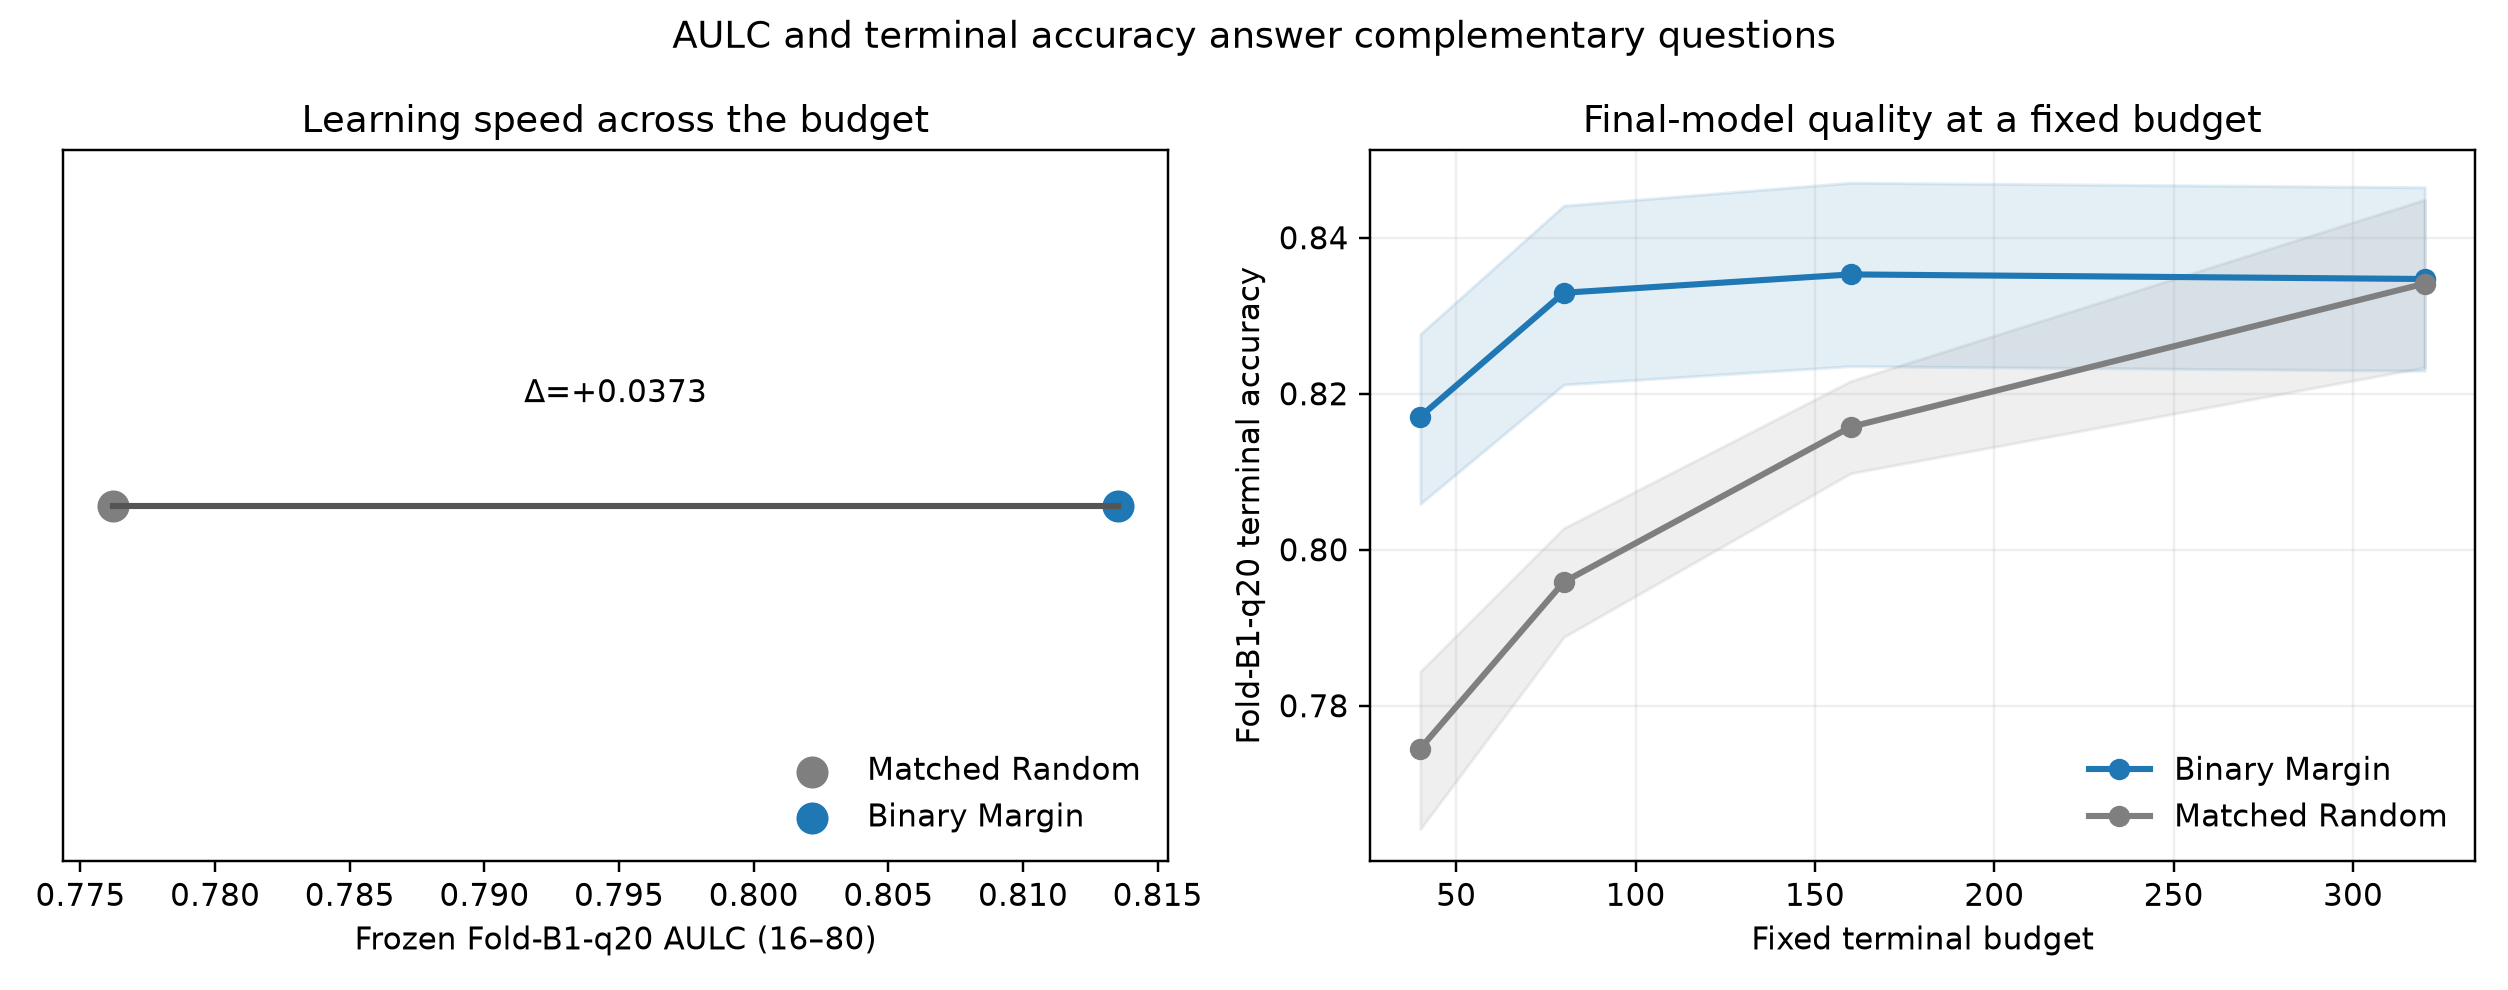

In [8]:
terminal = pd.read_csv(OUT / 'terminal_metric_summary.csv')
accuracy = terminal[(terminal.metric == 'accuracy') & terminal.estimand.isin(['binary_margin','binary_random','margin_minus_random'])]
display(accuracy.pivot_table(index=['budget','subset'], columns='estimand', values='point_estimate'))
display(Image(filename=str(OUT / 'figures' / '04_aulc_vs_terminal_performance_summary.png')))

**What do we see?** The table reports final-model quality at each fixed budget, separately from the frozen 16–80 AULC.

**Why does it matter?** Agreement strengthens the practical story; disagreement identifies a genuine estimand difference rather than an error.

**What can we claim?** Terminal results are post-hoc fixed-budget diagnostics.

**What can we NOT claim?** A terminal advantage alone does not prove faster learning across the entire budget range.

## 8. Full 81 versus q30 versus q20 performance

Full81 tests global prediction. Fold-B1-q30 (25 rows) and Fold-B1-q20 (17 rows) are nested, increasingly boundary-like held-out subsets.

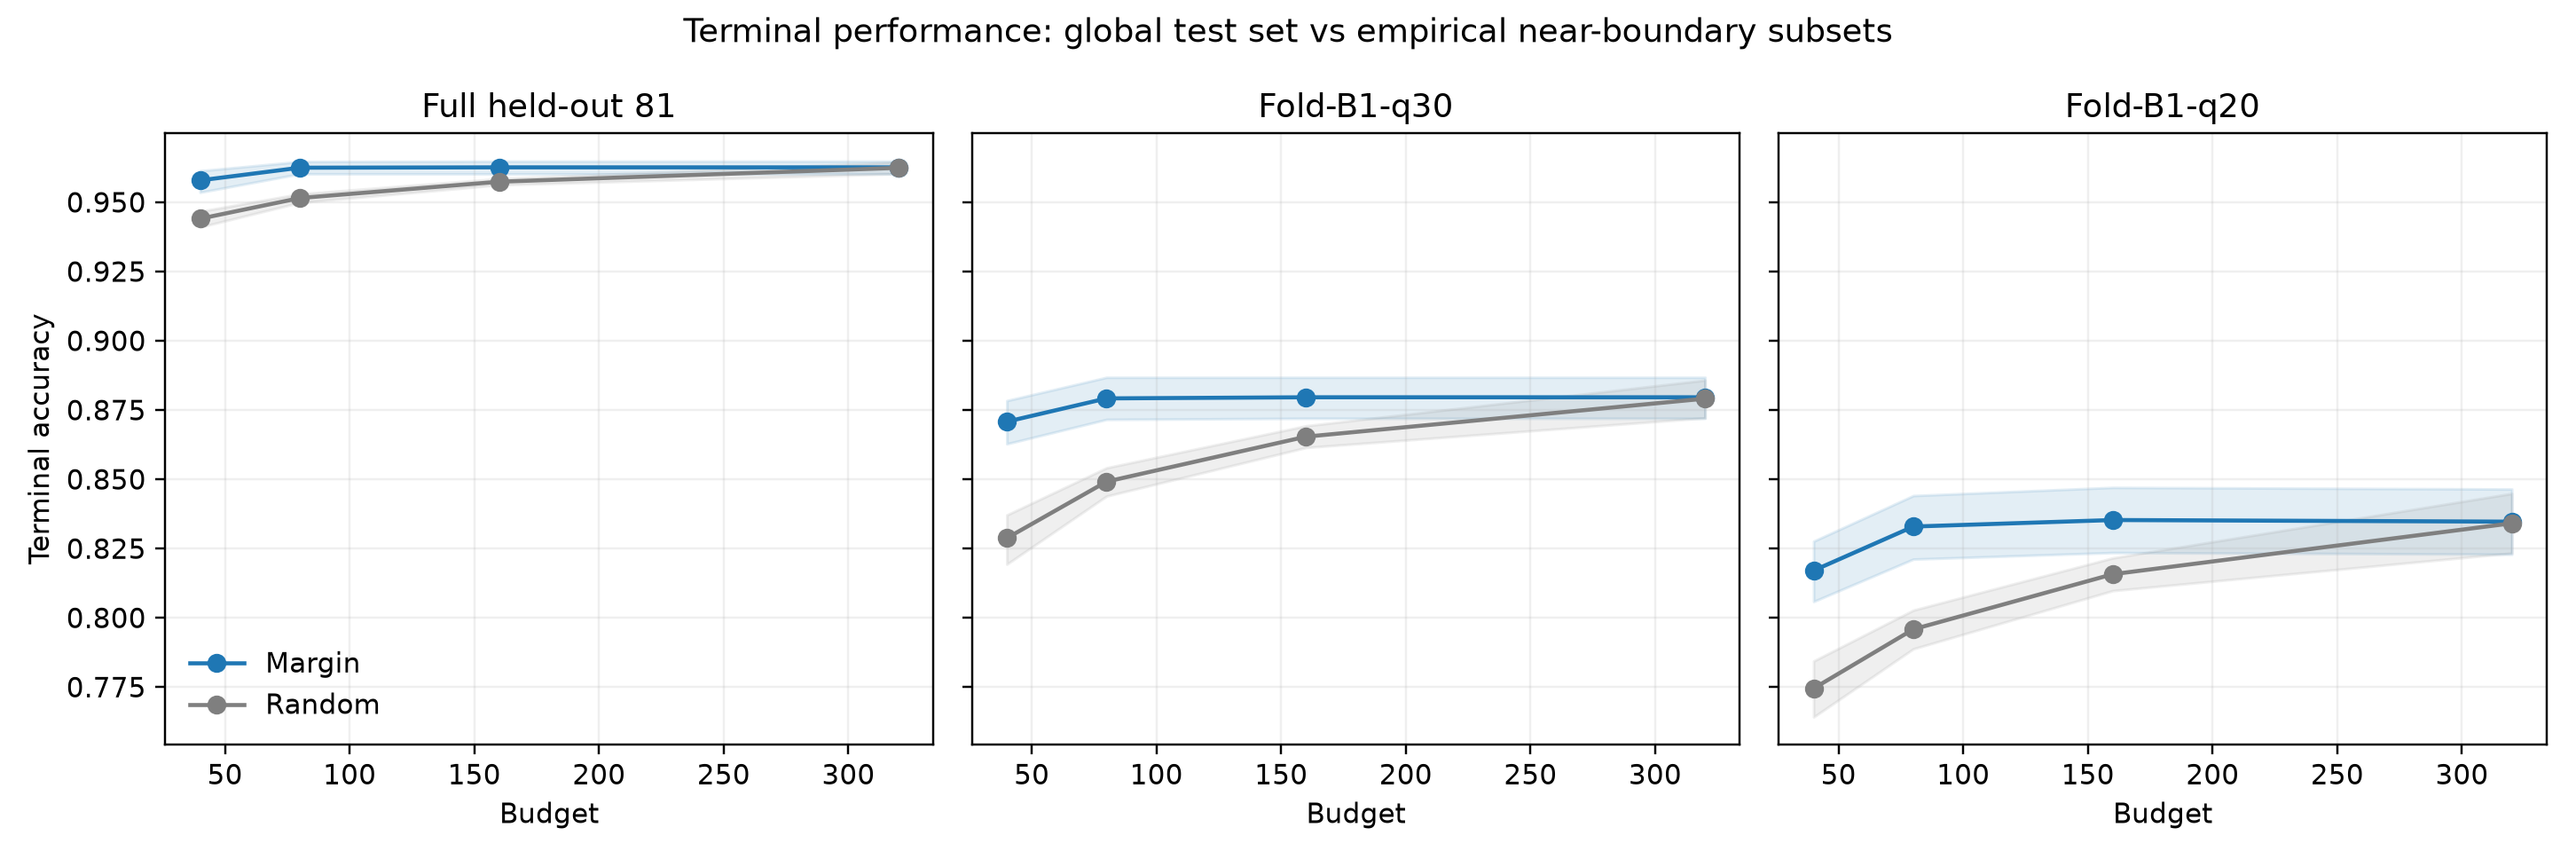

estimand                         binary_margin  binary_random
budget subset metric                                         
80     B1_q20 accuracy                0.832941       0.795863
              balanced_accuracy       0.813096       0.769190
              false_negative          1.740000       2.180667
              false_positive          1.100000       1.289667
              keyhole_recall          0.732381       0.663793
              specificity             0.893812       0.874587
       B1_q30 accuracy                0.879200       0.849160
              balanced_accuracy       0.849315       0.810724
              false_negative          1.880000       2.385667
              false_positive          1.140000       1.385333
              keyhole_recall          0.765998       0.704146
              specificity             0.932632       0.917302
       full81 accuracy                0.962469       0.951519
              balanced_accuracy       0.926029       0.902823
              false_negative          1.900000       2.520000
              false_positive          1.140000       1.407000
              keyhole_recall          0.869238       0.826837
              specificity             0.982820       0.978809
160    B1_q20 accuracy                0.835294       0.815745
              balanced_accuracy       0.814797       0.794257
              false_negative          1.770000       1.904333
              false_positive          1.030000       1.228000
              keyhole_recall          0.728504       0.707608
              specificity             0.901090       0.880907
       B1_q30 accuracy                0.879600       0.865387
              balanced_accuracy       0.848107       0.833251
              false_negative          1.940000       2.075000
              false_positive          1.070000       1.290333
              keyhole_recall          0.759501       0.743350
              specificity             0.936714       0.923151
       full81 accuracy                0.962593       0.957412
              balanced_accuracy       0.924558       0.916155
              false_negative          1.960000       2.156333
              false_positive          1.070000       1.293333
              keyhole_recall          0.865238       0.851794
              specificity             0.983878       0.980516
320    B1_q20 accuracy                0.834706       0.834118
              balanced_accuracy       0.814227       0.813686
              false_negative          1.770000       1.769667
              false_positive          1.040000       1.050333
              keyhole_recall          0.728365       0.728474
              specificity             0.900090       0.898899
       B1_q30 accuracy                0.879600       0.879107
              balanced_accuracy       0.848369       0.847883
              false_negative          1.930000       1.933000
              false_positive          1.080000       1.089333
              keyhole_recall          0.760612       0.760260
              specificity             0.936125       0.935505
       full81 accuracy                0.962593       0.962412
              balanced_accuracy       0.924840       0.924575
              false_negative          1.950000       1.955333
              false_positive          1.080000       1.089333
              keyhole_recall          0.865952       0.865563
              specificity             0.983727       0.983587

In [9]:
display(Image(filename=str(OUT / 'figures' / '03_terminal_accuracy_full_q30_q20.png')))
selected = terminal[(terminal.budget.isin([80,160,320])) & terminal.estimand.isin(['binary_margin','binary_random'])]
display(selected.pivot_table(index=['budget','subset','metric'], columns='estimand', values='point_estimate'))

**What do we see?** Global and near-boundary metrics are shown side by side, including recall, specificity, false negatives, and false positives in the table.

**Why does it matter?** A high global score can hide the harder empirical near-boundary subset.

**What can we claim?** q20/q30 quantify held-out difficulty under the manual labels.

**What can we NOT claim?** Their accuracies measure neither physical-boundary certainty nor causality.

## 9. PCA visualization and interpretation

PCA answers a narrow question: **which directions contain the most variation in the sampled four-input design?** It does not search for the direction that best separates Keyhole from Conduction. A supervised projection such as LDA would answer a different, label-dependent question and is outside this visualization-only analysis.

The primary PCA first standardizes `P`, `VX`, `LS`, and `ST`, because their physical units and numerical scales differ. Labels never enter the scaler or PCA fit. The global PCA coordinates also never enter GPC training or acquisition. Previously queried labels do train later GPC fits, as required by active learning.

,component,explained_variance_ratio,cumulative_explained_variance_ratio
0,PC1,0.319665,0.319665
1,PC2,0.264556,0.584221
2,PC3,0.250373,0.834594
3,PC4,0.165406,1.000000


,feature,PC1,PC2,PC3,PC4
0,P,-0.691489,0.320713,0.086506,0.641485
1,VX,-0.102898,-0.200776,0.964027,-0.140542
2,LS,0.710238,0.177552,0.207384,0.648867
3,ST,0.082564,0.908464,0.141985,-0.384338


,component,short_interpretation,explained_variance_ratio,scientific_scope
0,PC1,LS versus P contrast,0.319665,input-variance direction only; not physical im...
1,PC2,primarily ST variation,0.264556,input-variance direction only; not physical im...
2,PC3,primarily VX variation,0.250373,input-variance direction only; not physical im...
3,PC4,joint P + LS direction,0.165406,input-variance direction only; not physical im...
4,PC1,primarily P variation,0.472666,input-variance direction only; not physical im...
5,PC2,primarily ST variation,0.203697,input-variance direction only; not physical im...
6,PC3,primarily VX variation,0.182271,input-variance direction only; not physical im...
7,PC4,primarily LS variation,0.141365,input-variance direction only; not physical im...


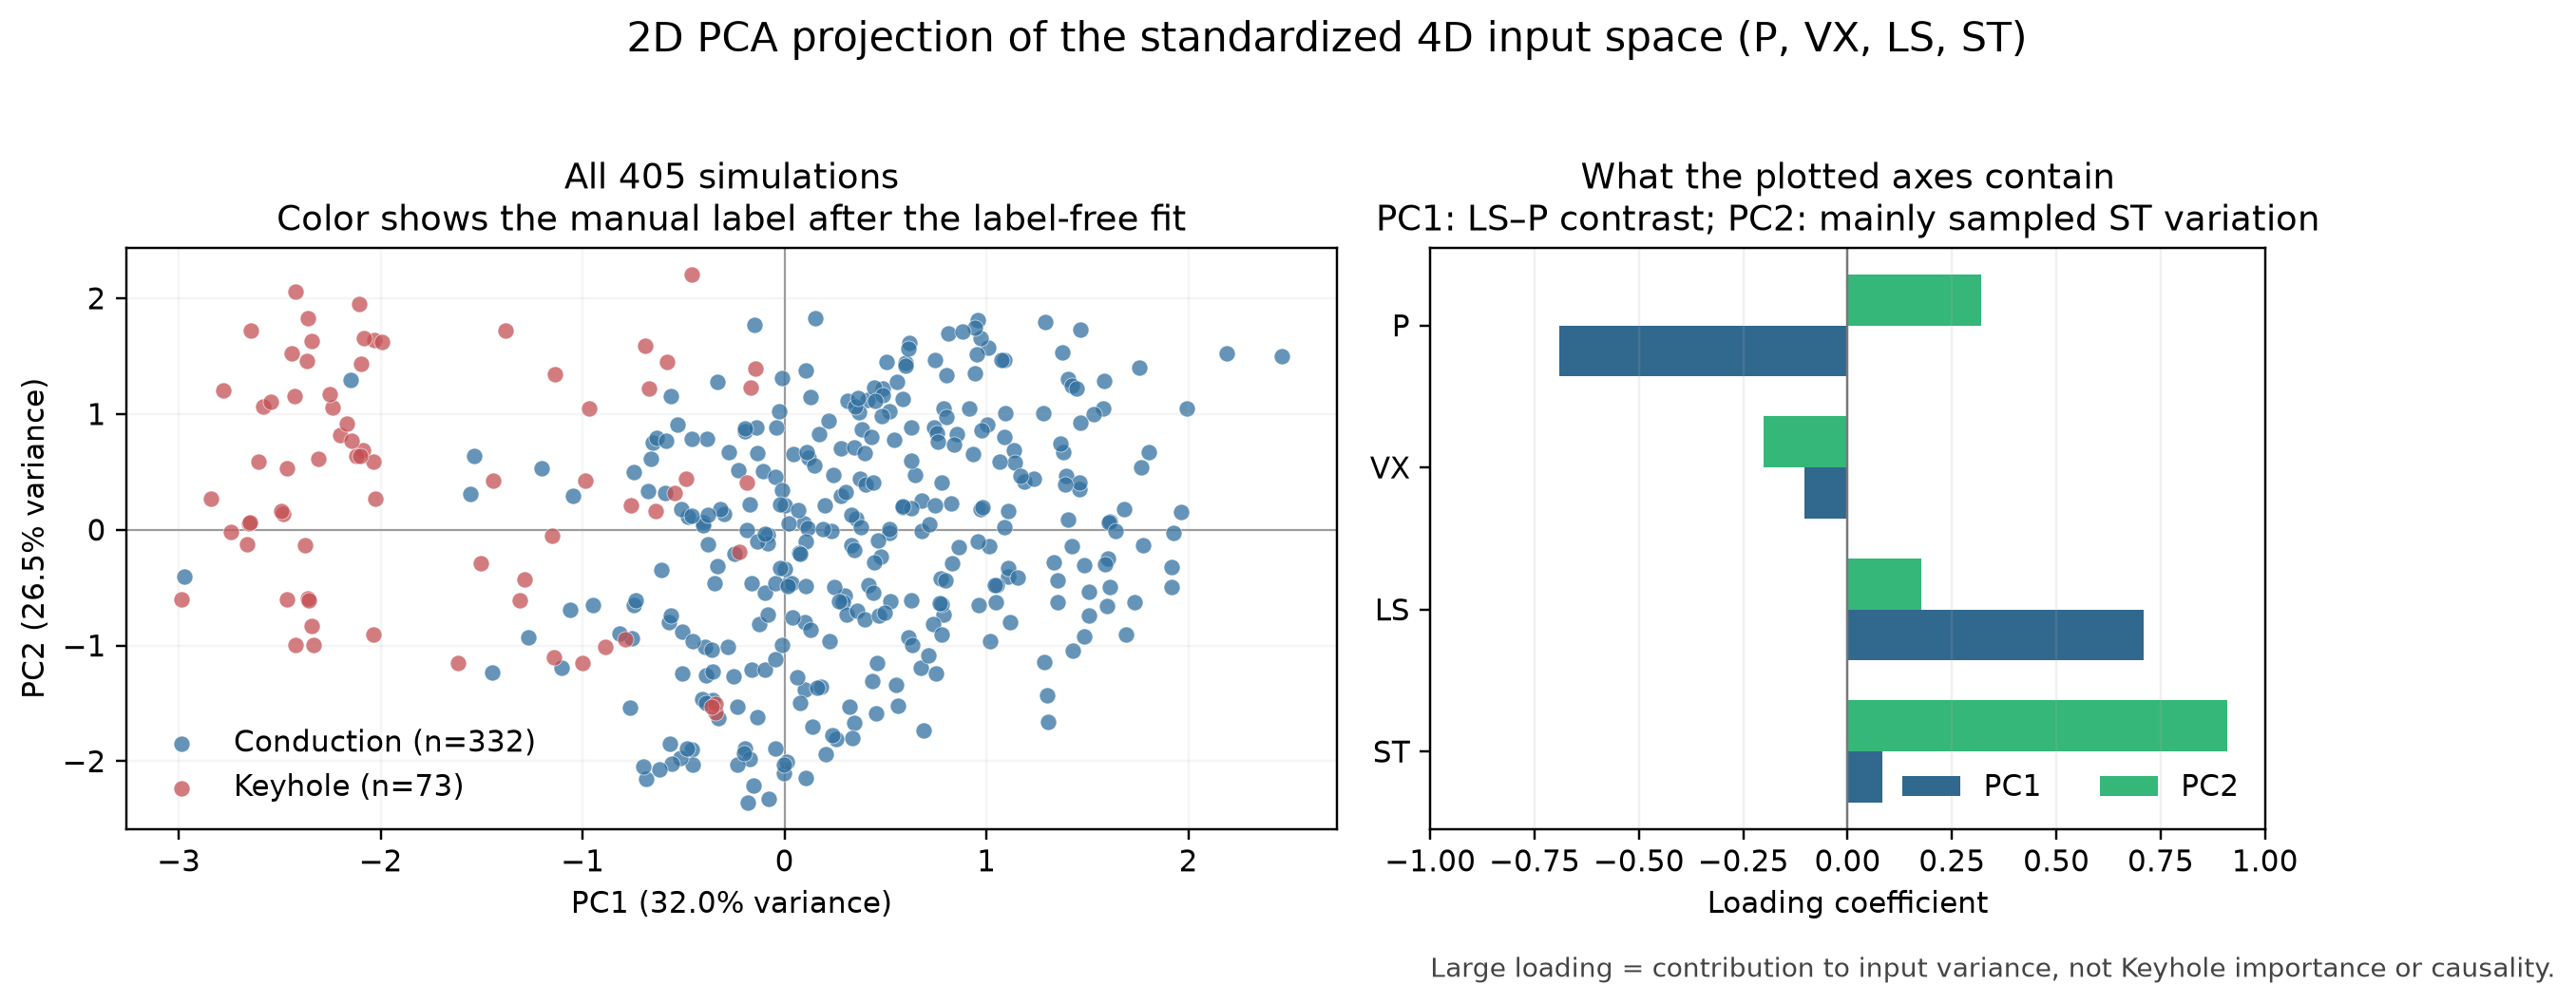

In [10]:
pca = json.loads((OUT / 'pca_summary.json').read_text(encoding='utf-8'))
variance = pd.read_csv(OUT / 'pca_explained_variance.csv')
loadings = pd.read_csv(OUT / 'pca_feature_loadings.csv')
interpretations = pd.read_csv(OUT / 'pca_component_interpretations.csv')
display(variance)
display(loadings)
display(interpretations[['component','short_interpretation','explained_variance_ratio','scientific_scope']])
display(Image(filename=str(OUT / 'figures' / '05_pca_input_geometry_and_loadings.png')))

**What do we see?** PC1 is an almost balanced LS-versus-P contrast, while PC2 is mainly sampled ST variation. Together they retain 58.42% of standardized input variance.

**Why does it matter?** The loading bars make the plotted axes physically readable and expose the 41.58% of variance omitted from the 2D view.

**What can we claim?** The Keyhole colors are an after-the-fact overlay on a label-free input-variance projection.

**What can we NOT claim?** A large loading is not physical importance, causal influence, or proof that a feature is the best Keyhole predictor.

### 9.1 Preprocessing robustness

StandardScaler is the declared primary view. RobustScaler is one sensitivity diagnostic, not a replacement. Each variant is shown in its own native explained-variance order; only the arbitrary sign is made deterministic by orienting the largest-magnitude coefficient positively.

,preprocessing,component,explained_variance_ratio,cumulative_explained_variance_ratio
0,standard,PC1,0.319665,0.319665
1,standard,PC2,0.264556,0.584221
2,standard,PC3,0.250373,0.834594
3,standard,PC4,0.165406,1.000000
4,robust,PC1,0.472666,0.472666
5,robust,PC2,0.203697,0.676364
6,robust,PC3,0.182271,0.858635
7,robust,PC4,0.141365,1.000000


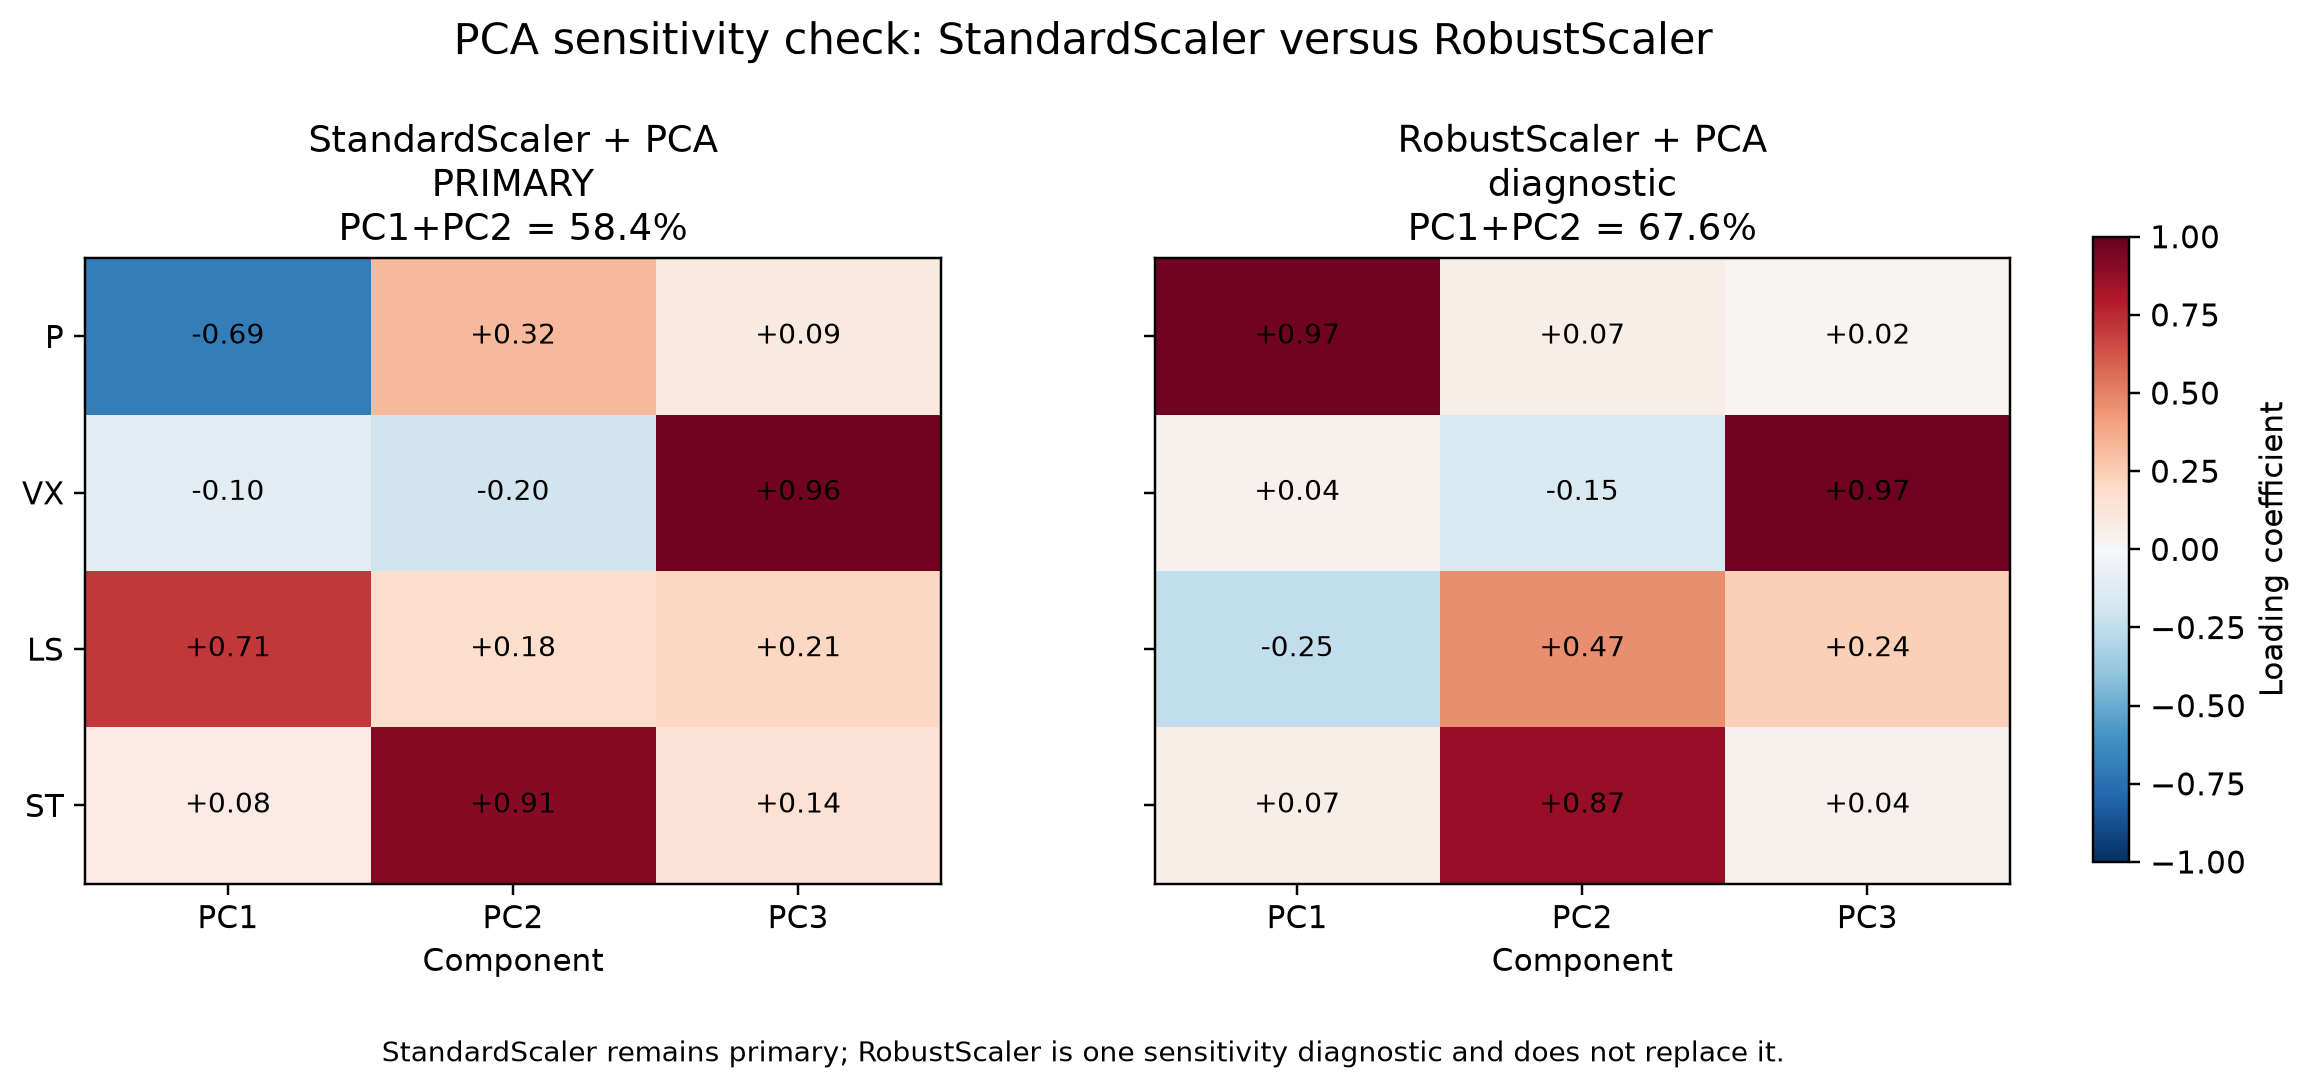

In [11]:
display(pd.read_csv(OUT / 'pca_scaling_explained_variance.csv'))
display(Image(filename=str(OUT / 'figures' / '06_pca_scaling_robustness.png')))

**What do we see?** Standard and robust scaling agree that PC2 is strongly ST-related and PC3 is strongly VX-related, but they materially disagree on PC1.

**Why does it matter?** The sensitivity check distinguishes stable component structure from conclusions that depend on preprocessing.

**What can we claim?** The ST/PC2 and VX/PC3 pattern is qualitatively robust; the exact PC1 interpretation is scaling-dependent.

**What can we NOT claim?** The sensitivity result turns either representation into physical importance or causal evidence.

### 9.2 What the main 2D view leaves out

PC3 explains 25.04%, nearly as much as PC2, and is overwhelmingly associated with `VX`. Therefore the PC1–PC2 scatter necessarily hides most scan-velocity variation.

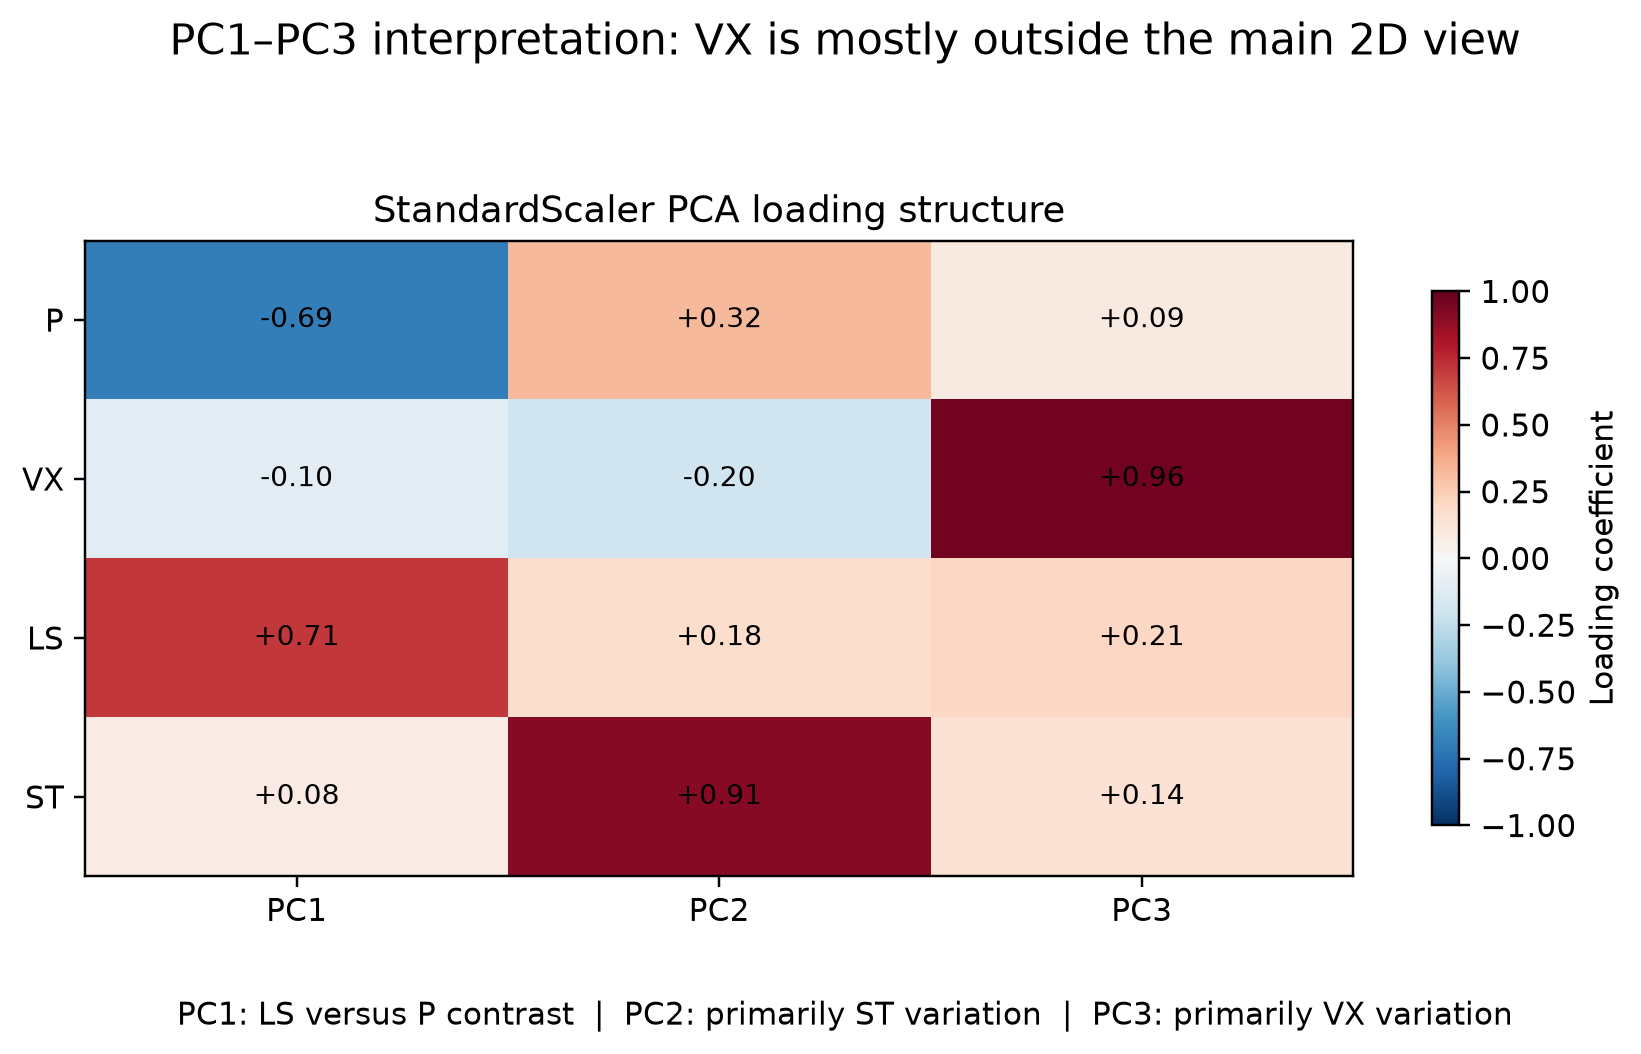

In [12]:
display(Image(filename=str(OUT / 'figures' / '07_pca_component_loading_structure.png')))

**What do we see?** PC1 is the P–LS contrast, PC2 is mainly ST, and PC3 is mainly VX in the primary StandardScaler PCA.

**Why does it matter?** Showing PC3 prevents the 2D plot from silently erasing an input direction that carries one quarter of standardized variance.

**What can we claim?** The PC1–PC3 coefficient panel makes the omitted VX-heavy direction explicit.

**What can we NOT claim?** Component coefficients are causal or predictive feature importance.

### 9.3 Boundary-like held-out subsets

The representative fold is chosen deterministically from label-informed q20 difficulty summaries, not from visual appearance. This choice is visualization-only and does not affect PCA, model fitting, acquisition, or performance estimates. q20 is nested inside q30 and is defined using opposite-label proximity in standardized 4D input space.

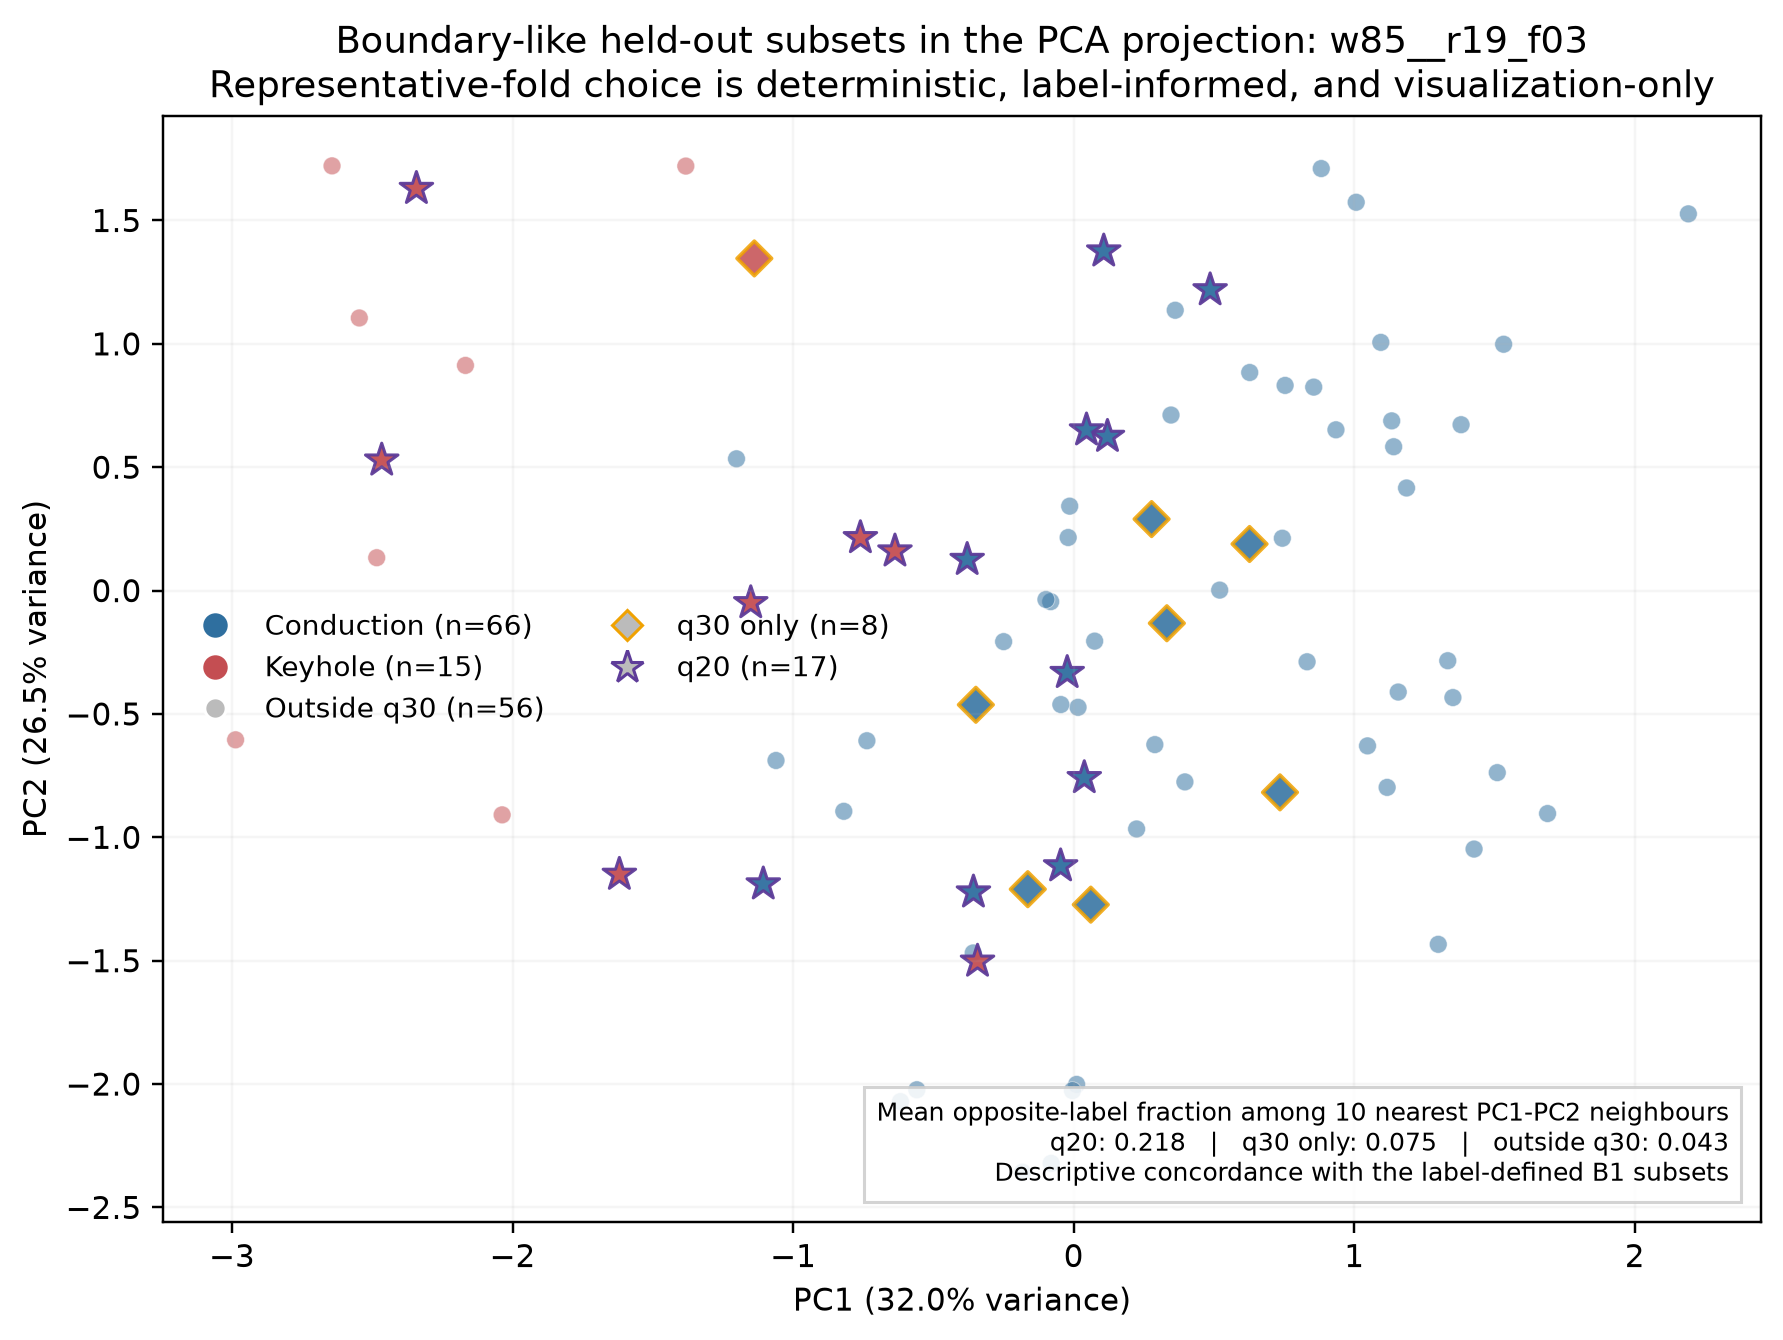

,count,mean
representative_test_role,,
B1_q20,17,0.217647
B1_q30_only,8,0.075000
held_out_non_q30,56,0.042857
not_in_representative_test,324,0.095370


In [13]:
display(Image(filename=str(OUT / 'figures' / '08_pca_boundary_like_subset.png')))
diagnostics = pd.read_csv(OUT / 'pca_interpretation_diagnostics.csv')
display(diagnostics.groupby('representative_test_role')['opposite_label_fraction_10nn_in_pc1_pc2'].agg(['count','mean']))

**What do we see?** The q20 points show more class mixing in this PC1–PC2 projection than held-out points outside q30.

**Why does it matter?** This gives an interpretable 2D picture of the evaluation subset used for the frozen near-boundary metric.

**What can we claim?** The projection is descriptively concordant with q20 being boundary-like in the frozen empirical definition.

**What can we NOT claim?** Because q20 itself uses labels and 4D opposite-class distance, this is not independent boundary validation or a physical-boundary proof.

### 9.4 Where Margin spends queries

The panels are mutually exclusive query stages. Color is an after-the-fact 10-nearest-neighbour class-mixing diagnostic in PC1–PC2. Held-out test rows and the four pool rows still unqueried at H320 are kept separate in the saved diagnostics.

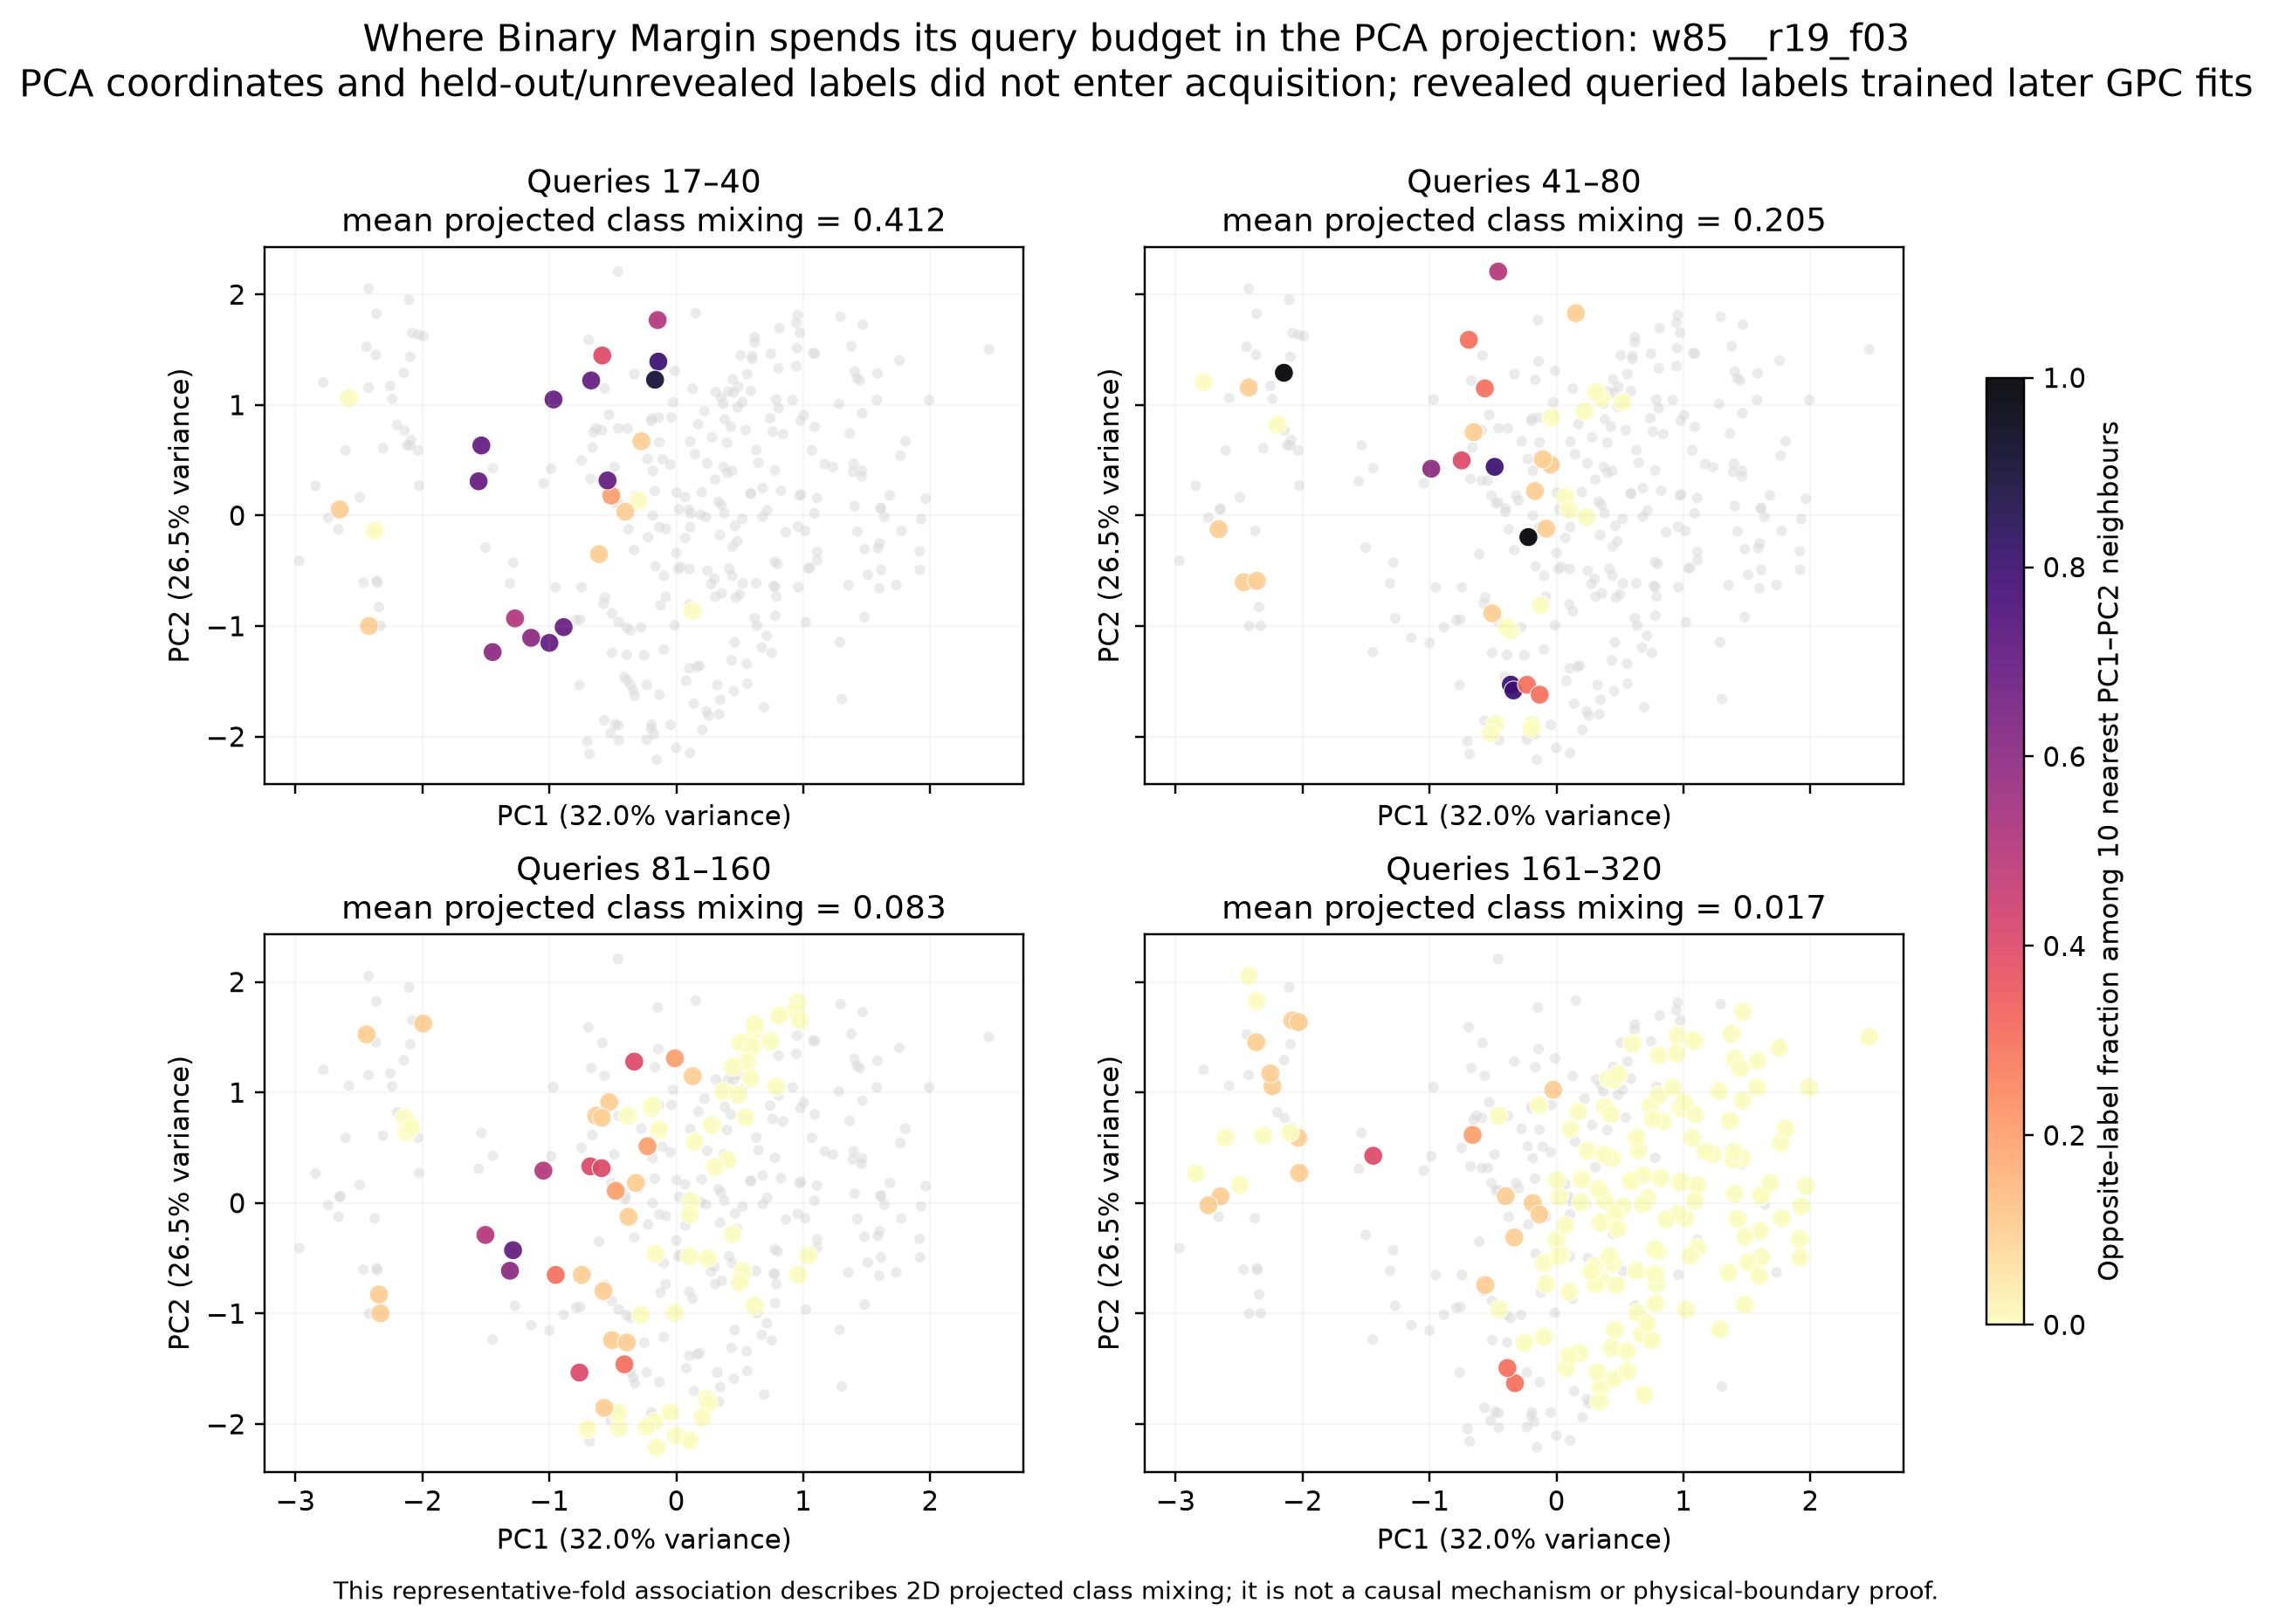

,count,mean
margin_query_stage,,
initial_1_16,16,0.218750
acquired_17_40,24,0.412500
acquired_41_80,40,0.205000
acquired_81_160,80,0.082500
acquired_161_320,160,0.016875
unqueried_pool_by_h320,4,0.000000
held_out_test,81,0.082716


In [14]:
display(Image(filename=str(OUT / 'figures' / '09_pca_margin_query_trajectory.png')))
stage = diagnostics.groupby('margin_query_stage')['opposite_label_fraction_10nn_in_pc1_pc2'].agg(['count','mean'])
display(stage.loc[['initial_1_16','acquired_17_40','acquired_41_80','acquired_81_160','acquired_161_320','unqueried_pool_by_h320','held_out_test']])

**What do we see?** Queries 17–40 have mean projected class mixing 0.412, compared with 0.205 for 41–80, 0.083 for 81–160, and 0.017 for 161–320.

**Why does it matter?** The exclusive stages show early concentration near 2D class overlap followed by broader coverage as the finite pool is exhausted.

**What can we claim?** This representative fold shows a descriptive association between early Margin queries and projected class mixing.

**What can we NOT claim?** The association is not causal, is not a performance estimate, and cannot establish that every early query lies on the true 4D boundary.

### 9.5 Secondary model-slice diagnostic

This final panel is deliberately secondary. It evaluates the representative-fold H320 GPC on a PC1–PC2 grid while fixing PC3=PC4=0. Only observed points with `|PC3| <= 0.5` and `|PC4| <= 0.5` are overlaid, so points far from the displayed slice are not presented as pointwise checks.

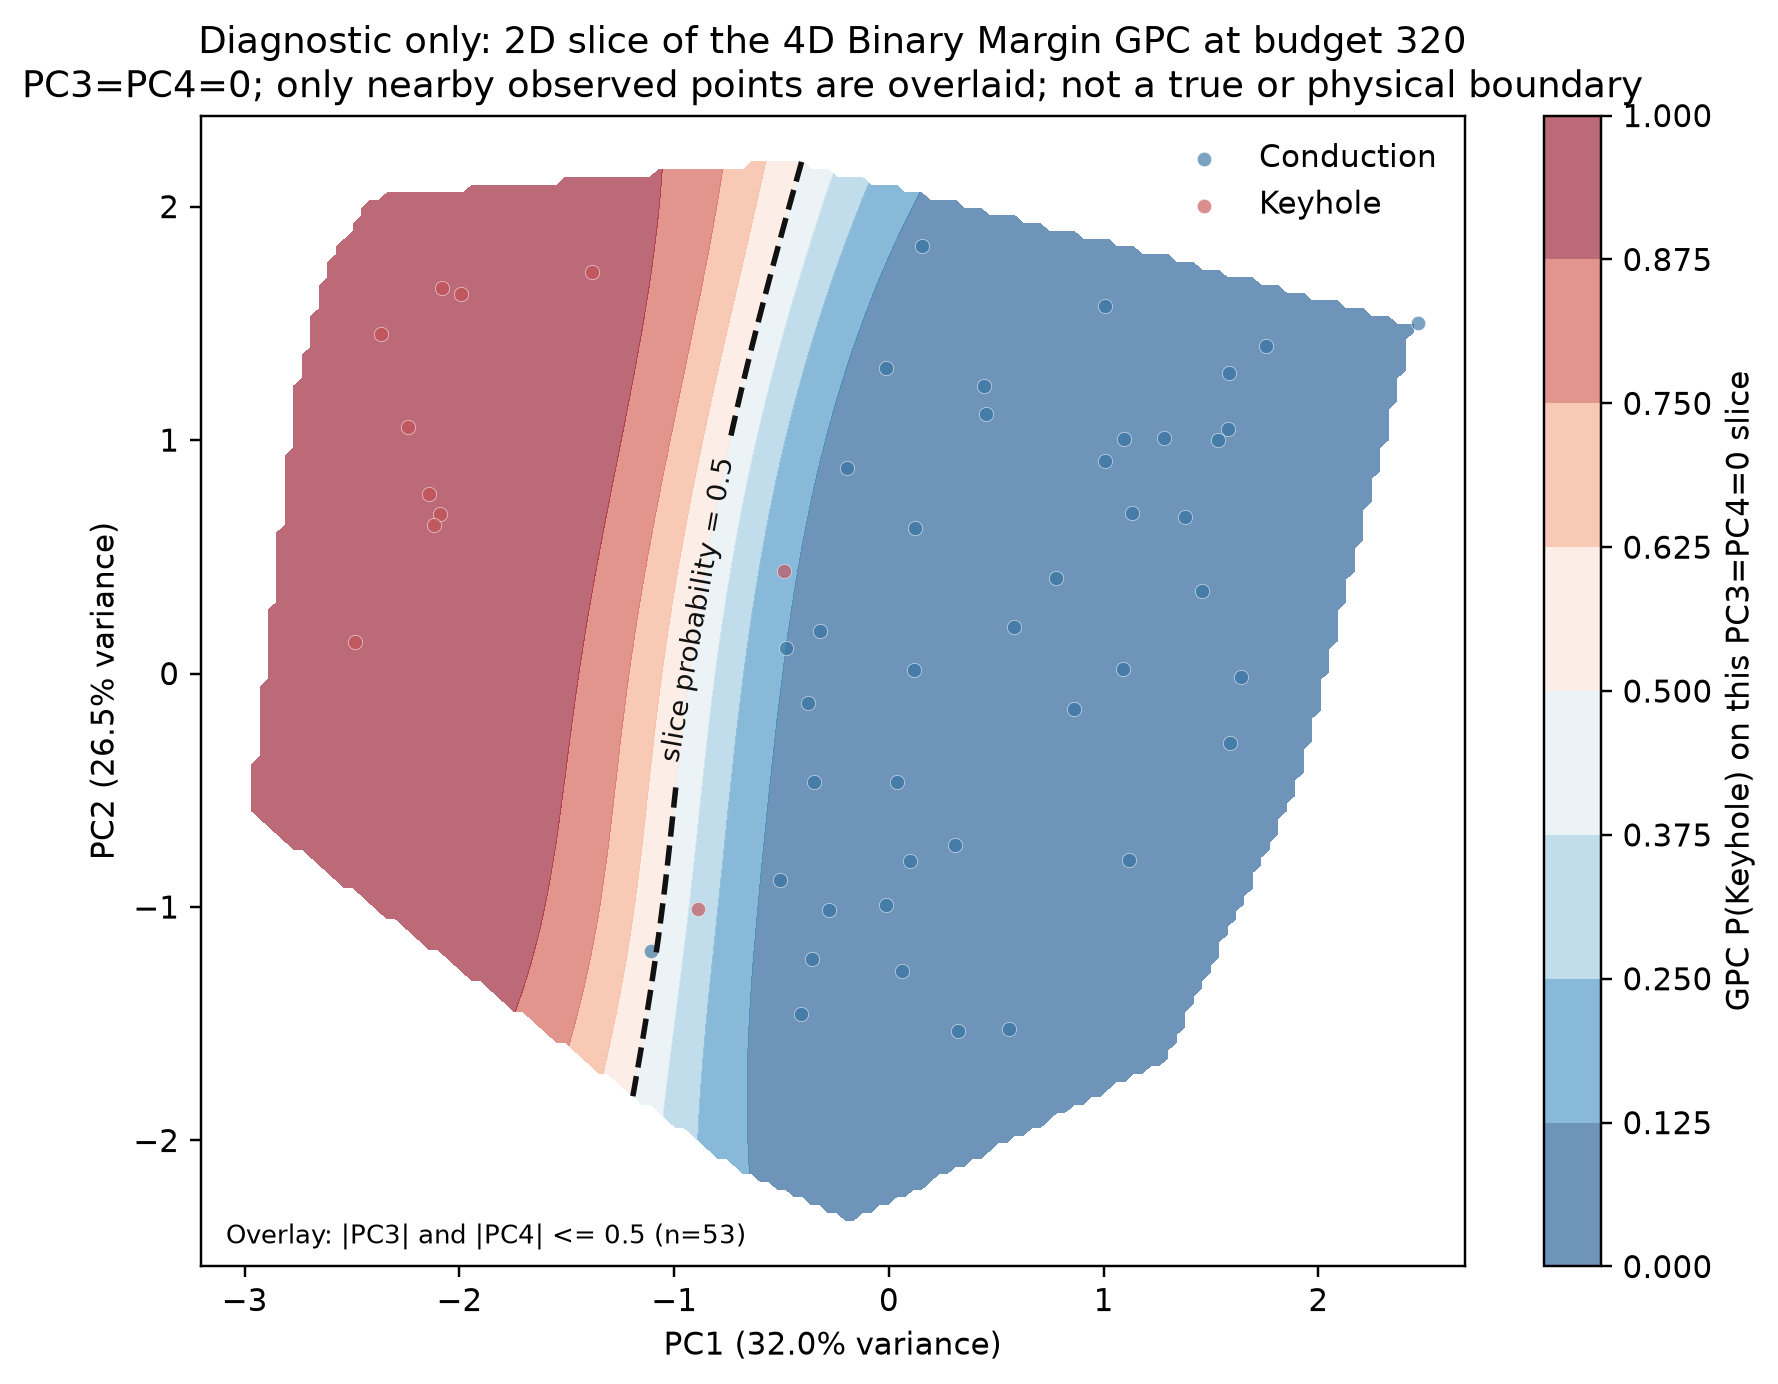

role                                           secondary diagnostic only
overlay tolerance                                                    0.5
overlay point count                                                   53
caveat                 Two-dimensional PCA-plane classifier slice mas...
dtype: object

In [15]:
display(Image(filename=str(OUT / 'figures' / '10_pca_gpc_slice_diagnostic.png')))
display(pd.Series({
    'role': pca['slice_role'],
    'overlay tolerance': pca['slice_overlay_tolerance_absolute_pc3_pc4'],
    'overlay point count': pca['slice_overlay_point_count'],
    'caveat': pca['slice_caveat'],
}))

**What do we see?** The dashed 0.5 contour belongs to one declared PC3=PC4=0 model slice inside the projected 2D hull.

**Why does it matter?** It can help inspect one cross-section of the fitted 4D classifier while keeping the geometry limitation visible.

**What can we claim?** It is a model diagnostic for one representative fold and one slice at budget 320.

**What can we NOT claim?** The contour is not the full 4D empirical boundary, not verified support on the observed 4D manifold, and not a physical Keyhole boundary.

## 10. Claim ledger

Frozen confirmatory claims and new post-hoc diagnostics are deliberately separated.

In [16]:
ledger = pd.read_csv(OUT / 'claim_ledger.csv')
display(ledger[['category','claim','status','strongest_safe_wording','must_not_use']])

,category,claim,status,strongest_safe_wording,must_not_use
0,frozen_confirmatory,Margin improves Fold-B1-q20 AULC vs matched Ra...,CONFIRMED_FROZEN_WEEK8_5,"Under the frozen Week 8.5 analysis, uncertaint...",PCA or q20 proves the physical boundary.
1,posthoc_H320,Persistent target attainment by H320,POSTHOC_DIAGNOSTIC,The longer horizon reduces unresolved trajecto...,H320 was preregistered or upgrades the old QUA...
2,posthoc_H320,At least X average query saving,NOT_SUPPORTED_MARGIN_TAIL_UNRESOLVED,An 'at least X queries saved on average' claim...,Every unresolved H320 Random path has Q>320.
3,posthoc_terminal,Terminal accuracy complements AULC,DESCRIPTIVE_POSTHOC,AULC answers how quickly learning improves; te...,Terminal accuracy and AULC are the same estimand.
4,posthoc_visualization,PCA clarifies 4D sampled-input geometry,VISUAL_DIAGNOSTIC,Standardized PCA is a label-free view of sampl...,"PCA maximizes Keyhole separation, proves featu..."


**What do we see?** Each claim has a category, status, safe wording, and prohibited wording.

**Why does it matter?** This prevents post-hoc evidence from being relabeled as frozen confirmation.

**What can we claim?** The ledger is the authoritative language guide for the supervisor summary.

**What can we NOT claim?** No claim may be strengthened by omitting its assumptions or status.

## 11. Limitations

- H=320 was chosen after the frozen H=160 analysis.
- Results describe a fixed 405-simulation population plus split/acquisition randomness.
- The manual label is ground truth for this benchmark, not an error-free physical oracle.
- q20 contains 17 rows per fold, so a single classification changes accuracy by about 5.9 percentage points.
- PCA PC1+PC2 discards 41.58% of standardized 4D input variance, including most VX variation in PC3.
- PCA maximizes sampled-input variance rather than Keyhole/Conduction separation; PC1 is also materially scaling-sensitive.
- The persistent-Q start can be tail-indeterminate at the final horizon because two future checkpoints are needed.
- No new simulator or prospective physical validation was performed.

**What do we see?** The main uncertainty is interpretive scope, not missing arithmetic.

**Why does it matter?** These limits define what belongs in thesis conclusions versus future validation.

**What can we claim?** The analysis closes the retrospective sample-efficiency evidence as far as H=320 permits.

**What can we NOT claim?** It does not establish universal transfer, causal physics, or online experimental safety.

## 12. Supervisor-ready conclusions

The concise 5–8-message version is stored in `supervisor_summary.md`.

In [17]:
display(Markdown((OUT / 'supervisor_summary.md').read_text(encoding='utf-8')))

# Week 9 Phase 1 — supervisor-ready messages

1. **The remaining question was censoring, not method selection.** Frozen Week 8.5 already confirmed a positive Fold-B1-q20 AULC contrast of +0.0373; Phase 1 only continued the same Margin and Random trajectories.

2. **The H=320 extension is explicitly post-hoc.** It does not rewrite the H=160 protocol or upgrade the old Week 8.5 QUALIFY ledger.

3. **Persistent target attainment at H=320:** Binary Margin reached the persistent 0.80 Fold-B1-q20 target in 91/100 outer runs; Random reached it in 2727/3000 continuations (90.9%), leaving 273 unresolved.

4. **Restricted H=320 burden:** Margin averaged 53.470 queries and matched Random 78.466; the descriptive difference is 24.996 queries and the ratio is 1.467×.

5. **Safe query-saving statement:** An 'at least X queries saved on average' claim is not identified because at least one Margin crossing remains unresolved at H=320. The naive argument that every unresolved H=320 path has `Q>320` is false under the frozen start-of-three definition.

6. **AULC and terminal accuracy answer different questions.** The terminal Fold-B1-q20 accuracy comparison has positive point estimates at 40, 80, 160, and 320, but the H320 contrast is practically zero and its design-conditional 95% interval [-0.0011, +0.0023] crosses zero. The frozen AULC contrast remains positive and measures earlier learning speed; balanced accuracy and Keyhole recall are separate descriptive endpoints, and full81, q30, and q20 results remain separated in `terminal_metric_summary.csv`.

7. **PCA describes sampled-input variance, not Keyhole importance.** After standardizing `P`, `VX`, `LS`, and `ST`, PC1 is an LS-versus-P contrast, PC2 is mainly sampled ST variation, and PC3 is mainly VX variation. PC1+PC2 retain 58.4%, so the 2D view omits 41.6% including most VX variation. The single RobustScaler sensitivity check preserves the ST/PC2 and VX/PC3 pattern but changes PC1 materially, so the interpretation is scaling-aware. In the representative, label-informed visualization fold, mean 10-neighbour opposite-label mixing is 0.218 for q20 versus 0.043 outside q30 (higher); Margin queries 17–40 average 0.412 versus 0.017 for queries 161–320 (higher); this is descriptive 2D association, not proof of a physical boundary. Labels do not enter PCA fitting; the representative-fold choice is explicitly label-informed and visualization-only. PCA coordinates and held-out or unrevealed labels did not enter acquisition, while labels of already queried rows trained later GPC fits.

8. **Main limitations:** fixed 405-simulation population, manual labels, 17-row q20 subsets, post-hoc H=320 choice, unobservable persistent-Q tail near the final horizon, design-conditional bootstrap uncertainty, and PCA that optimizes input variance rather than class separation. The secondary GPC slice fixes PC3=PC4=0 and is masked only by the projected 2D hull—not verified support on the observed 4D manifold or a physical boundary.
